In [1]:
import numpy as np
import os 
import matplotlib.pyplot as plt
import pandas as pd
import sys
import pickle
from copy import deepcopy

from GroupMultiNeSS.data_generation import LatentPositionGenerator
from GroupMultiNeSS.utils import frobenius_error, hard_thresholding_operator
from GroupMultiNeSS.shared_space_hunting import SharedSpaceHunt
from GroupMultiNeSS.multiness import MultiNeSS, MultiNeSSCV

from tqdm import tqdm

sys.path.append(os.path.abspath(".."))
from utils.average_initializer import AverageMultiNeSS

**COMMENT** Following notation of MacDonald et al. (2022), in the following notebook, we denote the shared component of the MultiNeSS model as $F$.

# Utils

In [2]:
def compare_models_across_param_grid(param_grid: dict[str, list],
                                     model_2_fitter: dict[str, object],
                                     extra_sample_kwargs={}, 
                                     model_2_extra_fit_kwargs={}, 
                                     random_seed=1,
                                     relative_errors=True):

    from itertools import product
    error_dicts = {model: {} for model in model_2_fitter}
    param_names = param_grid.keys()
    for param_tuple in product(*param_grid.values()):
        # sample data
        cur_params_dict = dict(zip(param_names, param_tuple))
        lpg = LatentPositionGenerator(**cur_params_dict, **extra_sample_kwargs)
        lpg.generate(random_seed)
        As = lpg.As

        for model, fitter in model_2_fitter.items():
            tmp_fitter = deepcopy(fitter)
            if model in model_2_extra_fit_kwargs:
                extra_fit_kwargs = model_2_extra_fit_kwargs[model]
            else:
                extra_fit_kwargs = {}                
            S_hat = tmp_fitter.fit(As, **extra_fit_kwargs).get_shared_latent_space()
            error = frobenius_error(lpg.S, S_hat, relative=relative_errors)
            error_dicts[model][param_tuple] = error

    return error_dicts
    

def plot_init_error_vs_two_variables(estimator_2_error_dict, var_names,
                                     error_ticks=None, fontsize=14):
    
    fig, axs = plt.subplots(ncols=len(estimator_2_error_dict), figsize=(20, 7))
    x_var_name, other_var_name = var_names
    
    for ax, (est_name, est_error_dict) in zip(axs, estimator_2_error_dict.items()):
        x_var_range, other_var_range = zip(*est_error_dict.keys())
        x_var_range = sorted(np.unique(x_var_range))
        other_var_range = sorted(np.unique(other_var_range))
        for other_var in other_var_range:
            errors = [est_error_dict[(x_var, other_var)] for x_var in x_var_range]
            ax.plot(x_var_range, errors, label=f"{other_var_name} = {other_var}")

        ax.set_xticks(x_var_range)
        ax.set_xlabel(x_var_name, fontsize=fontsize)
        ax.set_title(est_name, fontsize=fontsize)
        if error_ticks is not None:
            ax.set_yticks(error_ticks)
        ax.set_ylabel("$||F - \hat{F}||_F\ /\ ||F||_F$", fontsize=fontsize)
        ax.legend(fontsize=fontsize - 2)
    y_min = min([ax.get_ylim()[0] for ax in axs])
    y_max = max([ax.get_ylim()[1] for ax in axs])
    for ax in axs:
        ax.set_ylim(y_min, y_max)
    plt.show()

## SSH accuracy of rank estimation 

In [7]:
M = 5
n_simulations = 100
n_range = [50, 100, 200, 400]
sigma = 1
d_range = [3, 10]
d_2_rank_estimates_over_n = {d: {n: [] for n in n_range} for d in d_range}

for d in d_range:
    d_shared = d
    d_individs = [d] * M
    for n in n_range:
        for iteration in tqdm(range(n_simulations)):
            lpg = LatentPositionGenerator(n_nodes=n, n_layers=M, noise_sigma=sigma, 
                                      d_shared=d_shared, d_individs=d_individs)
            lpg.generate(iteration)
            As = lpg.As
            ssh = SharedSpaceHunt(d_individs=None, d_shared=None).fit(As)
            d_2_rank_estimates_over_n[d][n].append([ssh.d_shared_, *ssh.d_individs_])

# with open(f"saved_results/ssh_rank_estimation_acuracy_sigma_{sigma}_M_{M}.pkl", "wb") as f:
#     pickle.dump(d_2_rank_estimates_over_n, f)

In [42]:
# with open(f"saved_results/ssh_rank_estimation_acuracy_sigma_{sigma}_M_{M}.pkl", "rb") as f:
#     d_2_rank_estimates_over_n = pickle.load(f)\

In [52]:
prop_fully_correct_estimates = {d: {} for d in d_range}
prop_pm1_correct_estimates = {d: {} for d in d_range}

for d in d_range:
    for n in n_range:
        true_ranks = np.array([d] * (M + 1))
        rank_estimates = np.array(d_2_rank_estimates_over_n[d][n])
        if_corrects_array = rank_estimates == true_ranks
        pm1_corrects_array = (rank_estimates >= true_ranks - 1) & (rank_estimates <= true_ranks + 1)
        prop_fully_correct_estimates[d][n] = round(np.mean(np.all(if_corrects_array, axis=1)), 2)
        prop_pm1_correct_estimates[d][n] = round(np.mean(np.all(pm1_corrects_array, axis=1)), 2)

In [54]:
print("Fully correct rank estimates for d_shared and d_individs")       
pd.DataFrame(np.vstack([list(prop_fully_correct_estimates[d].values()) for d in d_range]),
    index=[f"d={d}" for d in d_range], columns=n_range)

Fully correct rank estimates for d_shared and d_individs


,50,100,200,400
d=3,0.0,0.07,0.67,0.97
d=10,0.0,0.00,0.00,0.11


In [55]:
print("+ / - 1 correct rank estimates for d_shared and d_individs") 
pd.DataFrame(np.vstack([list(prop_pm1_correct_estimates[d].values()) for d in d_range]),
    index=[f"d={d}" for d in d_range], columns=n_range)

+ / - 1 correct rank estimates for d_shared and d_individs


,50,100,200,400
d=3,0.09,0.68,1.0,1.00
d=10,0.00,0.00,0.0,0.67


# Compare initializers

# 1. Oracle scenario (both models know true ranks)

In [29]:
# ranks of sampled parameters
d_shared = 4
d_inidivid = 4

## Vary n & sigma with  M = 10

In [30]:
model_2_fitter = {"Shared space hunting": SharedSpaceHunt(d_shared=d_shared, d_individs=d_inidivid),
                  "Truncated average": AverageMultiNeSS(d_shared=d_shared, d_individs=d_inidivid)}

In [32]:
sigma_range = np.round(np.linspace(0, 3, 7), 2)
n_range = [50, 100, 200, 300]


param_grid = {"n_nodes": n_range, "noise_sigma": sigma_range}
extra_sample_kwargs={"n_layers": 10,  "d_shared": d_shared, "d_individs": d_inidivid}
errors_dict = compare_models_across_param_grid(param_grid=param_grid, 
                                               model_2_fitter=model_2_fitter,
                                               extra_sample_kwargs=extra_sample_kwargs)

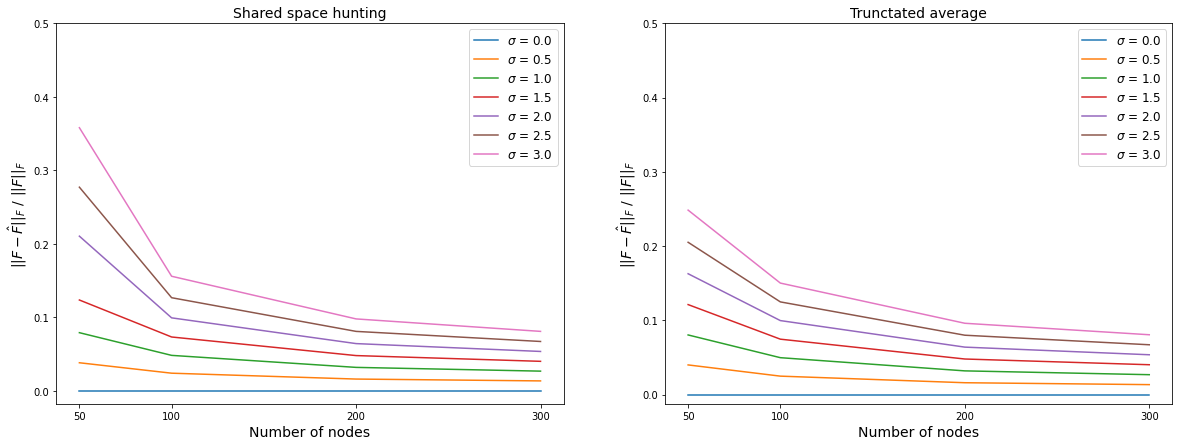

In [13]:
plot_init_error_vs_two_variables(errors_dict, var_names = ["Number of nodes", "$\sigma$"],
                                 error_ticks=np.linspace(0., 0.5, 6).round(2))

## Vary m & sigma with n =100

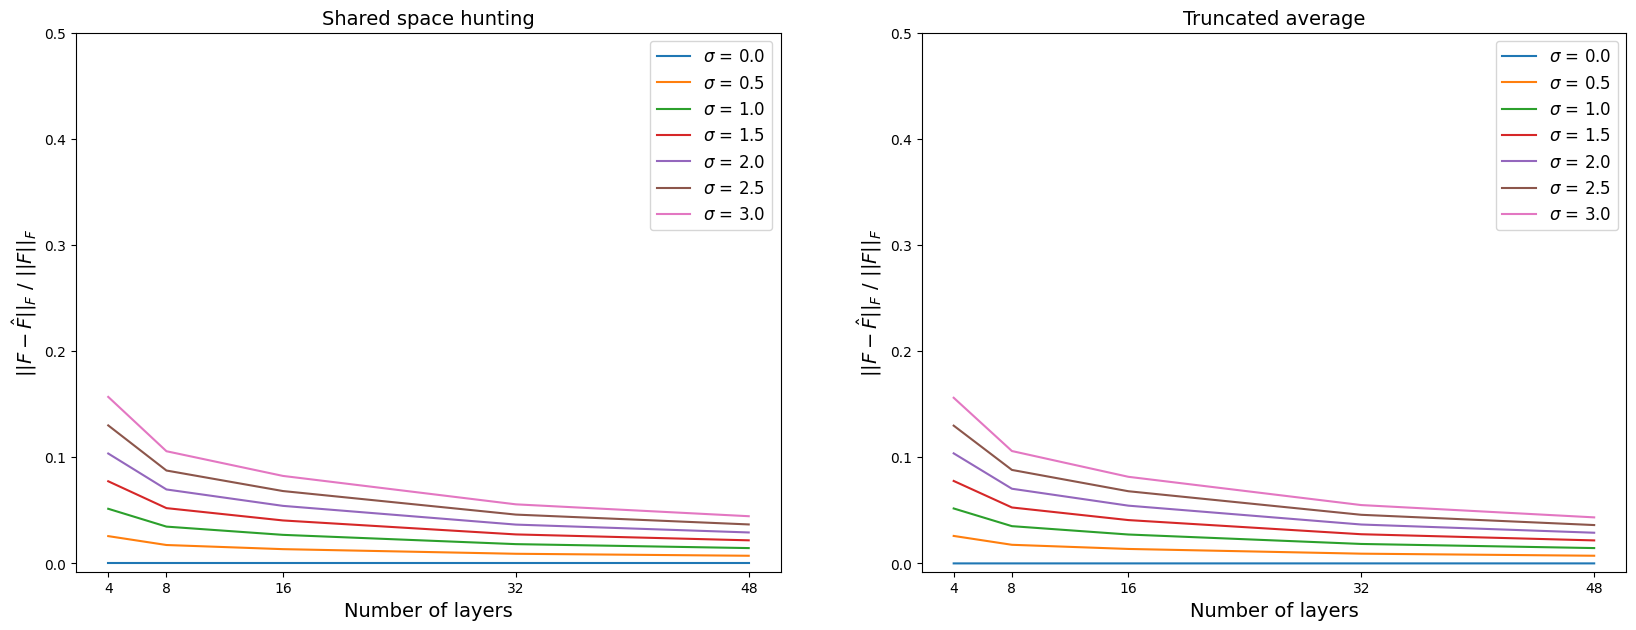

In [50]:
sigma_range = np.round(np.linspace(0, 3, 7), 2)
M_range = [4, 8, 16, 32, 48]

param_grid = {"n_layers": M_range, "noise_sigma": sigma_range}
extra_sample_kwargs={"n_nodes": 200, "d_shared": d_shared, "d_individs": d_inidivid}

errors_dict = compare_models_across_param_grid(param_grid=param_grid, 
                                               model_2_fitter=model_2_fitter,
                                               extra_sample_kwargs=extra_sample_kwargs)
plot_init_error_vs_two_variables(errors_dict, var_names = ["Number of layers", "$\sigma$"],
                                 error_ticks=np.linspace(0., 0.5, 6).round(2))

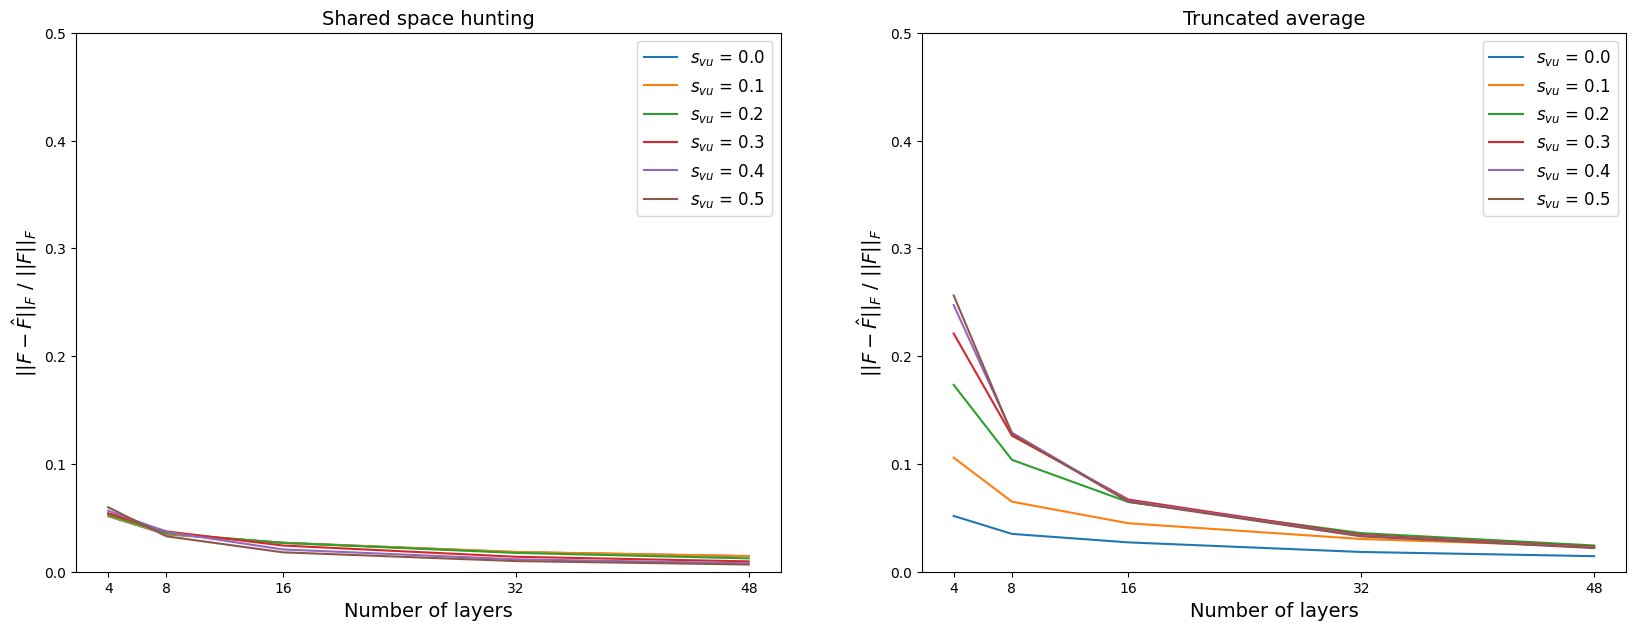

In [52]:
s_vu_range = np.round(np.linspace(0., 0.5, 6), 2)
M_range = [4, 8, 16, 32, 48]

param_grid = {"n_layers": M_range, "s_vu": s_vu_range}
extra_sample_kwargs={"n_nodes": 200, "noise_sigma": 1., "d_shared": d_shared, "d_individs": d_inidivid}

errors_dict = compare_models_across_param_grid(param_grid=param_grid, 
                                               model_2_fitter=model_2_fitter,
                                               extra_sample_kwargs=extra_sample_kwargs)

plot_init_error_vs_two_variables(errors_dict, var_names = ["Number of layers", "$s_{vu}$"], 
                                 error_ticks=np.round(np.linspace(0., 0.5, 6), 2))

# 2. Non-Oracle scenario: average not truncated, SSH ranks are estimated 

## Low-rank regime (d_shared = 4)

In [37]:
# ranks of sampled parameters
d_shared = 4
d_inidivid = 4

In [38]:
model_2_fitter = {"Shared space hunting": SharedSpaceHunt(d_shared=None, d_individs=None),
                  "Truncated average": AverageMultiNeSS(d_shared=None, d_individs=None)}

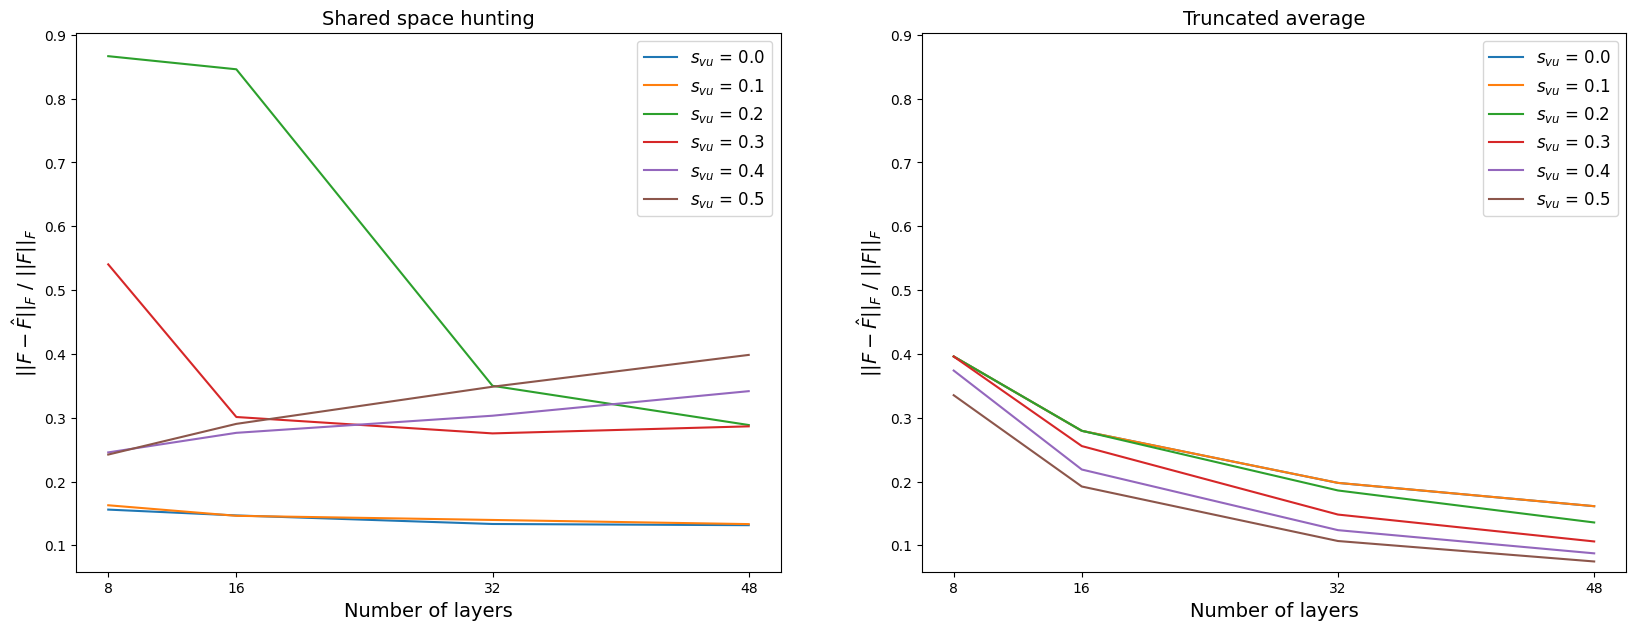

In [39]:
s_vu_range = np.round(np.linspace(0., 0.5, 6), 2)
M_range = [8, 16, 32, 48]

param_grid = {"n_layers": M_range, "s_vu": s_vu_range}
extra_sample_kwargs={"n_nodes": 200, "noise_sigma": 1., "d_shared": d_shared, "d_individs": d_inidivid}

errors_dict = compare_models_across_param_grid(param_grid=param_grid, 
                                               model_2_fitter=model_2_fitter,
                                               extra_sample_kwargs=extra_sample_kwargs)

plot_init_error_vs_two_variables(errors_dict, var_names = ["Number of layers", "$s_{vu}$"])

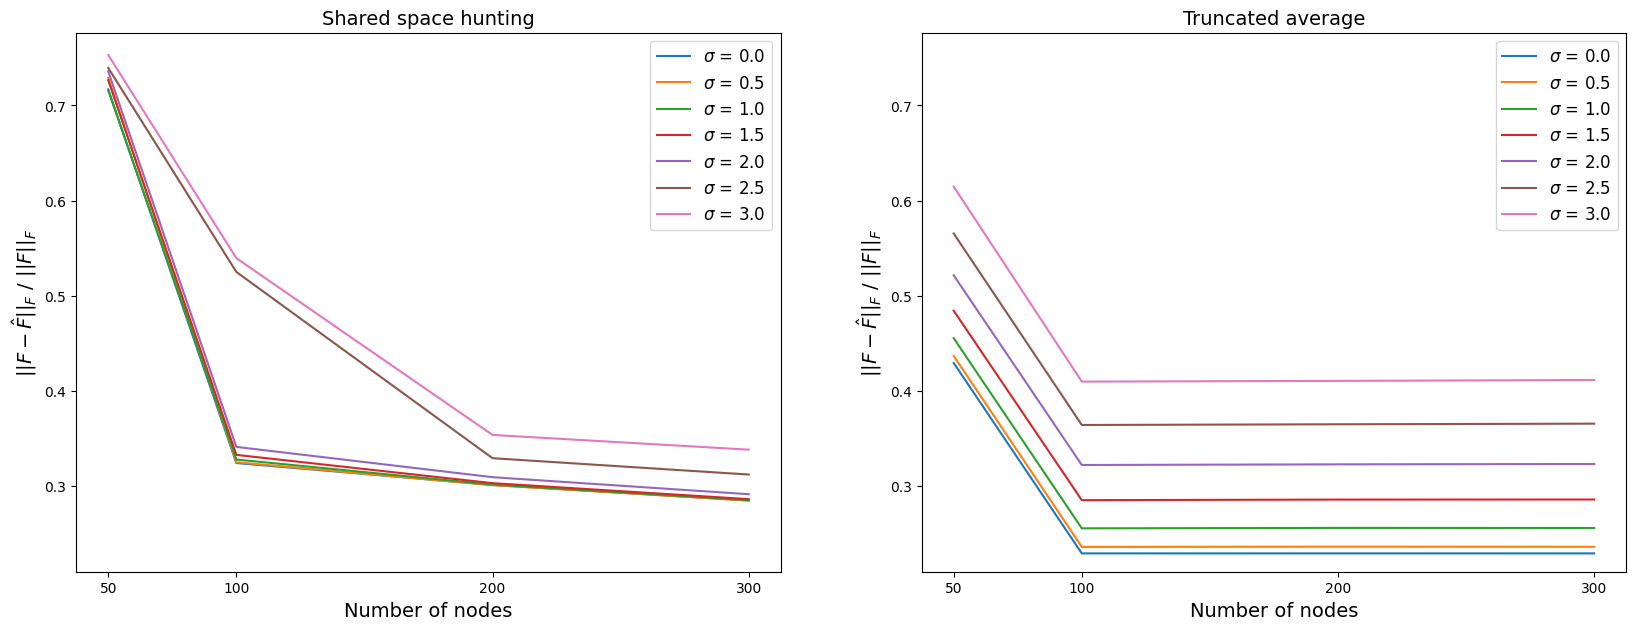

In [26]:
sigma_range = np.round(np.linspace(0, 3, 7), 2)
n_range = [50, 100, 200, 300]


param_grid = {"n_nodes": n_range, "noise_sigma": sigma_range}
extra_sample_kwargs={"n_layers": 16,  "s_vu": 0.3, "d_shared": d_shared, "d_individs": d_inidivid}

errors_dict = compare_models_across_param_grid(param_grid=param_grid, 
                                               model_2_fitter=model_2_fitter,
                                               extra_sample_kwargs=extra_sample_kwargs)

plot_init_error_vs_two_variables(errors_dict, var_names = ["Number of nodes", "$\sigma$"])

## High rank regime (d_shared = 8)

Set $d$ high to demonstrate the difficulties for SSH when rank is large and unknown

In [40]:
# ranks of sampled parameters
d_shared = 8
d_inidivid = 4

In [41]:
model_2_fitter = {"Shared space hunting": SharedSpaceHunt(d_shared=None, d_individs=None),
                  "Truncated average": AverageMultiNeSS(d_shared=None, d_individs=None)}

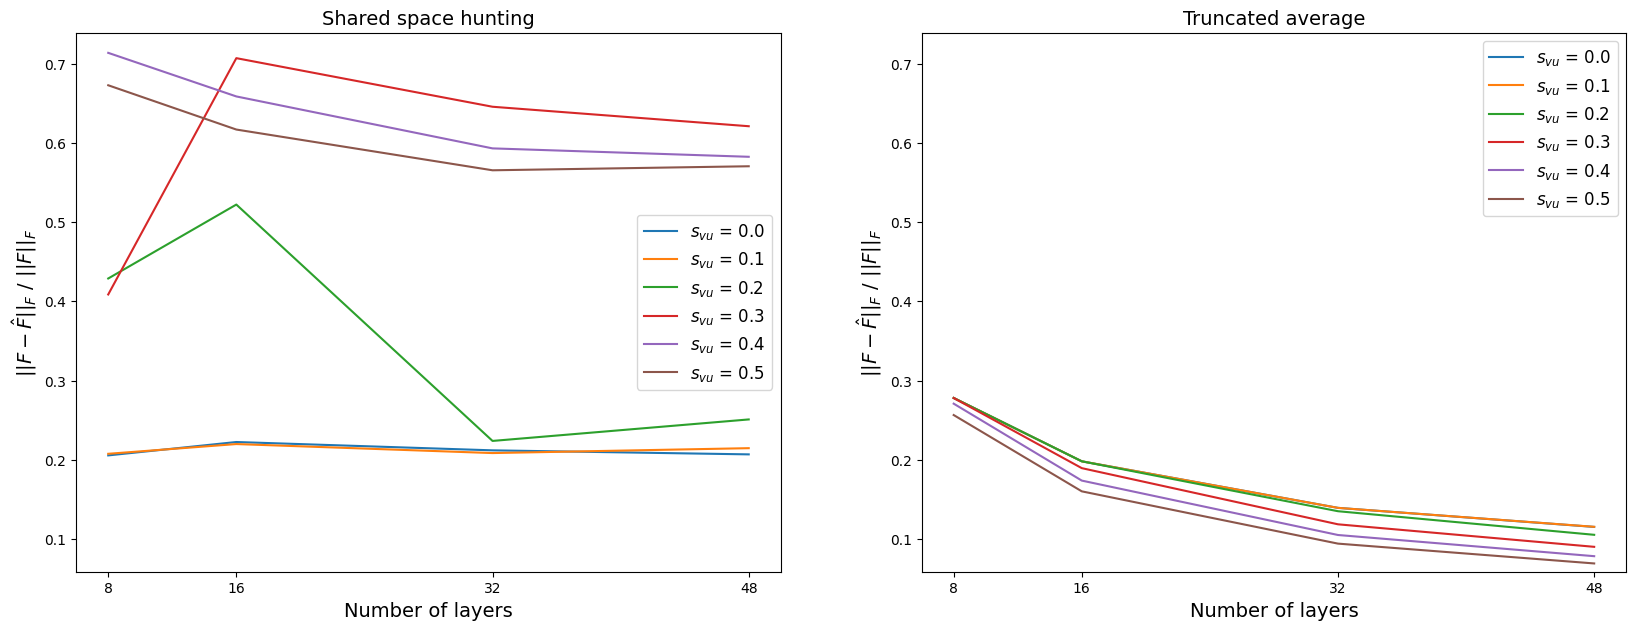

In [42]:
s_vu_range = np.round(np.linspace(0., 0.5, 6), 2)
M_range = [8, 16, 32, 48]

param_grid = {"n_layers": M_range, "s_vu": s_vu_range}
extra_sample_kwargs={"n_nodes": 200, "noise_sigma": 1., "d_shared": d_shared, "d_individs": d_inidivid}

errors_dict = compare_models_across_param_grid(param_grid=param_grid, 
                                               model_2_fitter=model_2_fitter,
                                               extra_sample_kwargs=extra_sample_kwargs)

plot_init_error_vs_two_variables(errors_dict, var_names = ["Number of layers", "$s_{vu}$"])